<a href="https://colab.research.google.com/github/rizkyhaksono/project-image-classification-dicoding/blob/main/submission/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar — Animals-10

**Submission Akhir — Belajar Pengembangan Machine Learning (Dicoding)**

Notebook ini membangun model *Convolutional Neural Network* (CNN) untuk mengklasifikasikan
gambar **10 jenis hewan** menggunakan dataset publik **[Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10)**
dari Kaggle (~26.000 gambar, resolusi tidak seragam).

Model dibangun dengan **`tf.keras.Sequential`** yang menggabungkan *transfer learning*
(basis **MobileNetV2**) dengan lapisan **`Conv2D`** dan **`MaxPooling2D`** buatan sendiri,
lalu diekspor ke tiga format: **SavedModel**, **TF-Lite**, dan **TensorFlow.js**.

## Pemenuhan Kriteria

| Kriteria / Saran | Pemenuhan |
|---|---|
| Dataset ≥ 1.000 gambar | Animals-10 (~26.000 gambar) |
| Bukan dataset RPS / X-Ray | Animals-10 (10 kelas hewan) |
| Split train / validation / test | 80% / 10% / 10% |
| Sequential + Conv2D + Pooling | Lihat sel **Arsitektur Model** |
| Akurasi train & test ≥ 85% | Target ≥ 95% (transfer learning + fine-tuning) |
| Plot akurasi & loss | Lihat sel **Visualisasi** |
| Ekspor SavedModel, TF-Lite, TFJS | Lihat sel-sel **Ekspor Model** |
| *(Saran)* Callback | EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, callback kustom |
| *(Saran)* Resolusi tidak seragam | Dibuktikan pada EDA (tanpa pra-resize manual) |
| *(Saran)* ≥ 10.000 gambar | ~26.000 gambar |
| *(Saran)* Akurasi ≥ 95% | Target arsitektur ini |
| *(Saran)* ≥ 3 kelas | 10 kelas |
| *(Saran)* Inferensi + bukti | Demo inferensi model TF-Lite di akhir notebook |

> **Catatan eksekusi:** jalankan di **Google Colab** dengan **Runtime → T4 GPU**
> (`Runtime → Change runtime type → T4 GPU`), lalu `Runtime → Run all`.

## 1. Persiapan & Unduh Dataset

### Autentikasi Kaggle
Kaggle mendukung **dua jenis kredensial** — sel di bawah menerima keduanya:

1. **`kaggle.json` (Legacy API Key)** — di halaman **Kaggle → Settings → API**, scroll ke
   *Legacy API Credentials* → klik **Create Legacy API Key** → berkas `kaggle.json` terunduh.
2. **Token akses baru `KGAT_...`** — tombol **Generate New Token** di bagian *API Tokens*.

Saat sel dijalankan: **unggah `kaggle.json`** bila punya, atau **batalkan unggahan** lalu
**tempel token `KGAT_...`** saat diminta (token tidak ikut tersimpan di notebook).

In [38]:
# Perlu kaggle CLI >= 1.8.0 agar token KGAT_ didukung; --upgrade memastikan versinya cukup baru.
!pip install -q --upgrade kaggle

In [39]:
import os
import getpass

KAGGLE_DIR = os.path.expanduser("~/.kaggle")
os.makedirs(KAGGLE_DIR, exist_ok=True)


def _have_kaggle_creds():
    return (os.path.exists(f"{KAGGLE_DIR}/kaggle.json")
            or os.path.exists(f"{KAGGLE_DIR}/access_token")
            or os.environ.get("KAGGLE_API_TOKEN"))


if not _have_kaggle_creds():
    uploaded = {}
    try:
        from google.colab import files
        print("Unggah kaggle.json (Legacy API Key). "
              "Klik 'Cancel' jika ingin memakai token KGAT_... sebagai gantinya.")
        uploaded = files.upload()
    except Exception:
        pass  # bukan di Colab atau unggahan dibatalkan

    if "kaggle.json" in uploaded or os.path.exists("kaggle.json"):
        # Opsi 1: kaggle.json (legacy)
        os.replace("kaggle.json", f"{KAGGLE_DIR}/kaggle.json")
        os.chmod(f"{KAGGLE_DIR}/kaggle.json", 0o600)
    else:
        # Opsi 2: token akses baru (KGAT_...) — input aman, tidak tercetak / tidak tersimpan.
        token = getpass.getpass("Tempel API token KGAT_... lalu Enter: ").strip()
        with open(f"{KAGGLE_DIR}/access_token", "w") as f:
            f.write(token)
        os.chmod(f"{KAGGLE_DIR}/access_token", 0o600)

print("Kredensial Kaggle siap.")

Kredensial Kaggle siap.


In [40]:
# Unduh & ekstrak dataset (~26k gambar). Diunduh sekali; lewati jika folder sudah ada.
if not os.path.isdir("data/raw-img"):
    !kaggle datasets download -d alessiocorrado99/animals10
    !unzip -q animals10.zip -d data
print("Isi folder data/:", os.listdir("data"))

Isi folder data/: ['raw-img', 'translate.py']


In [41]:
# Import seluruh library dan tetapkan seed agar hasil reproducible.
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU") or "TIDAK ADA — gunakan Runtime T4 GPU!")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Exploratory Data Analysis (EDA)

Kita memeriksa jumlah gambar per kelas dan **ragam resolusi gambar asli**. Dataset ini
berisi gambar dengan ukuran yang **tidak seragam** (memenuhi salah satu saran penilaian):
kita tidak melakukan pra-resize manual — proses *resize* hanya dilakukan di dalam pipeline
pelatihan ke ukuran input model.

In [42]:
from PIL import Image

DATA_DIR = "data/raw-img"

# Pemetaan nama folder (Bahasa Italia) -> Bahasa Inggris (dari translate.py milik dataset).
IT_TO_EN = {
    "cane": "dog",       "cavallo": "horse",  "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow",      "pecora": "sheep",   "ragno": "spider",
    "scoiattolo": "squirrel",
}


def explore_dataset(directory):
    """Cetak jumlah gambar per kelas + ragam resolusi (membuktikan resolusi tidak seragam)."""
    total_images = 0
    all_sizes = set()
    print(f"{'Kelas (IT)':<12}{'Kelas (EN)':<12}{'Jumlah':>8}")
    print("-" * 32)
    for subdir in sorted(os.listdir(directory)):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue
        image_files = os.listdir(subdir_path)
        total_images += len(image_files)
        print(f"{subdir:<12}{IT_TO_EN.get(subdir, '?'):<12}{len(image_files):>8}")
        # Sampel 200 gambar per kelas untuk mencatat ragam ukuran (cepat, cukup representatif).
        for img_file in image_files[:200]:
            try:
                with Image.open(os.path.join(subdir_path, img_file)) as img:
                    all_sizes.add(img.size)
            except Exception:
                pass
    print("-" * 32)
    print(f"TOTAL gambar          : {total_images}")
    print(f"Ragam resolusi unik   : {len(all_sizes)} ukuran berbeda (tidak seragam)")
    widths = [w for w, h in all_sizes]
    heights = [h for w, h in all_sizes]
    print(f"Lebar  (min..max)     : {min(widths)} .. {max(widths)} px")
    print(f"Tinggi (min..max)     : {min(heights)} .. {max(heights)} px")
    print(f"Contoh ukuran         : {list(sorted(all_sizes))[:8]} ...")
    return total_images


total = explore_dataset(DATA_DIR)

Kelas (IT)  Kelas (EN)    Jumlah
--------------------------------
cane        dog             4863
cavallo     horse           2623
elefante    elephant        1446
farfalla    butterfly       2112
gallina     chicken         3098
gatto       cat             1668
mucca       cow             1866
pecora      sheep           1820
ragno       spider          4821
scoiattolo  squirrel        1862
--------------------------------
TOTAL gambar          : 26179
Ragam resolusi unik   : 359 ukuran berbeda (tidak seragam)
Lebar  (min..max)     : 107 .. 5472 px
Tinggi (min..max)     : 86 .. 3648 px
Contoh ukuran         : [(107, 160), (120, 90), (120, 113), (127, 300), (139, 152), (147, 210), (149, 300), (150, 150)] ...


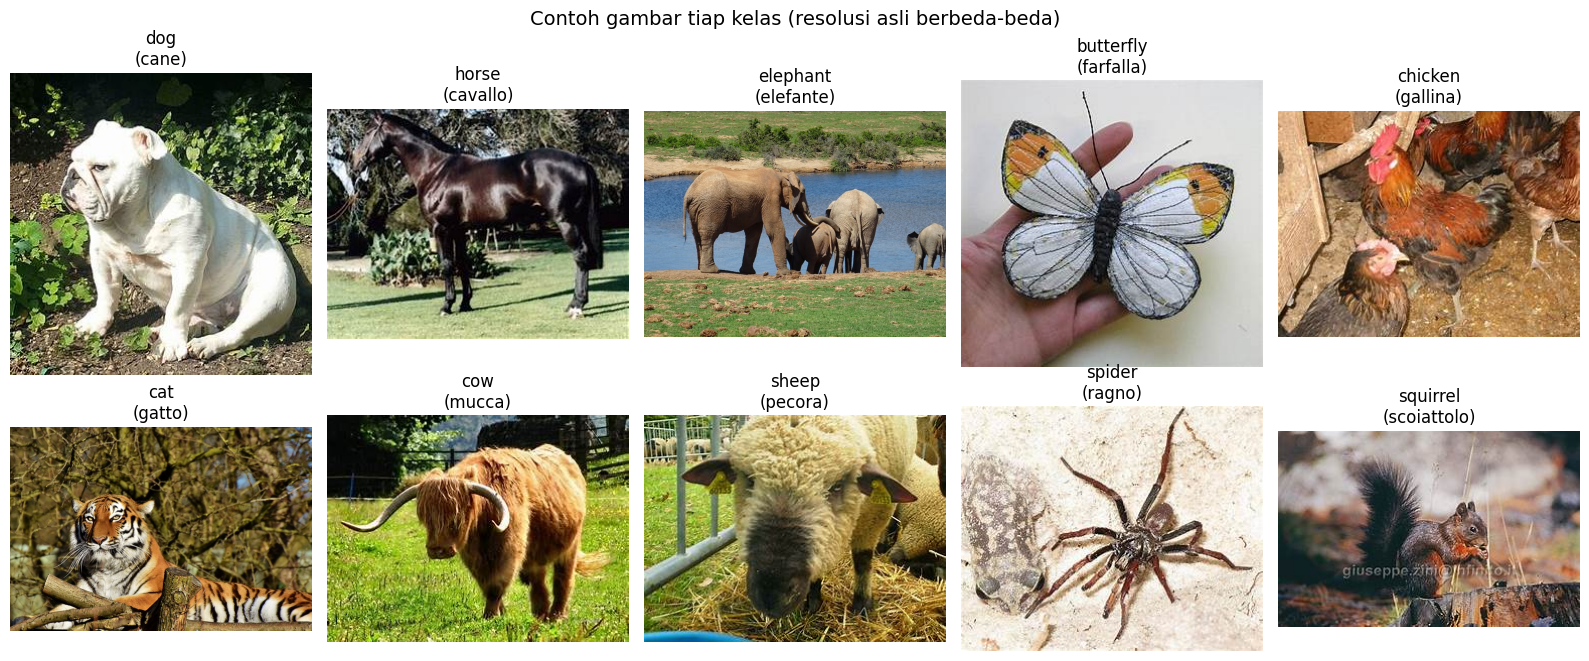

In [43]:
# Tampilkan beberapa contoh gambar dari tiap kelas.
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, subdir in zip(axes.ravel(), sorted(os.listdir(DATA_DIR))):
    subdir_path = os.path.join(DATA_DIR, subdir)
    if not os.path.isdir(subdir_path):
        continue
    sample = os.path.join(subdir_path, os.listdir(subdir_path)[0])
    ax.imshow(Image.open(sample))
    ax.set_title(f"{IT_TO_EN.get(subdir, subdir)}\n({subdir})")
    ax.axis("off")
plt.suptitle("Contoh gambar tiap kelas (resolusi asli berbeda-beda)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Membagi Dataset: Train / Validation / Test (80 / 10 / 10)

`image_dataset_from_directory` hanya mendukung pembagian dua arah (`validation_split`).
Karena itu kita ambil 20% sebagai himpunan validasi penuh, lalu **membaginya lagi**
menjadi *validation* dan *test* menggunakan `take`/`skip` — pola resmi dari tutorial
*transfer learning* TensorFlow. Hasilnya: **train 80% / validation 10% / test 10%**.

In [44]:
IMG_SIZE = (224, 224)   # ukuran input MobileNetV2
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH, label_mode="int",
)
val_full = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH, label_mode="int",
)

# Nama kelas mengikuti urutan alfabetis folder (Italia) -> indeks 0..9.
class_names = train_ds.class_names
en_class_names = [IT_TO_EN[c] for c in class_names]
num_classes = len(class_names)
assert num_classes == 10, f"Diharapkan 10 kelas, ditemukan {num_classes}: {class_names}"
print("Indeks kelas:", dict(enumerate(en_class_names)))

# Bagi himpunan validasi penuh menjadi validation (50%) dan test (50%).
val_batches = val_full.cardinality().numpy()
test_ds = val_full.take(val_batches // 2)
val_ds = val_full.skip(val_batches // 2)

# Optimasi pipeline. Validation/test di-cache (kecil) agar evaluasi deterministik & cepat.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)               # train: decode ulang tiap epoch (hemat RAM)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print(f"Batch  -> train: {train_ds.cardinality().numpy()}, "
      f"val: {val_ds.cardinality().numpy()}, test: {test_ds.cardinality().numpy()}")

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Indeks kelas: {0: 'dog', 1: 'horse', 2: 'elephant', 3: 'butterfly', 4: 'chicken', 5: 'cat', 6: 'cow', 7: 'sheep', 8: 'spider', 9: 'squirrel'}
Batch  -> train: 655, val: 82, test: 82


## 4. Arsitektur Model (Sequential + Conv2D + Pooling)

Model `Sequential` terdiri atas:
1. **Lapisan augmentasi** (`RandomFlip`, `RandomRotation`, `RandomZoom`) — hanya aktif saat
   *training* (otomatis non-aktif saat evaluasi/inferensi), sehingga augmentasi hanya
   diterapkan pada data latih.
2. **`Rescaling`** ke rentang `[-1, 1]` sesuai kebutuhan MobileNetV2 (lebih bersih untuk
   diekspor dibanding `Lambda preprocess_input`).
3. **Basis MobileNetV2** (`include_top=False`, bobot ImageNet) untuk *transfer learning*.
4. **Lapisan `Conv2D` + `MaxPooling2D` buatan sendiri** — memenuhi Kriteria 4 secara eksplisit.
5. Kepala klasifikasi `Dense` + `Dropout` + `softmax`.

In [45]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False  # tahap awal: bekukan basis

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="data_augmentation")

model = tf.keras.Sequential([
    tf.keras.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,                                   # augmentasi (train-only)
    layers.Rescaling(1.0 / 127.5, offset=-1),            # preprocessing MobileNetV2 [-1, 1]
    base_model,                                          # transfer learning
    layers.Conv2D(256, 3, padding="same", activation="relu"),   # Conv2D eksplisit
    layers.MaxPooling2D(),                                       # Pooling eksplisit
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
], name="animals10_classifier")

model.summary()

Model: "animals10_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,520,202 (21.06 MB)

 Trainable params: 3,262,218 (12.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Callback

Kita memakai empat callback (memenuhi saran "mengimplementasikan callback"), termasuk satu
**callback kustom** yang menghentikan pelatihan saat akurasi validasi mencapai target.

In [46]:
class StopAtAccuracy(tf.keras.callbacks.Callback):
    """Hentikan pelatihan ketika val_accuracy mencapai ambang target."""

    def __init__(self, target=0.96):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        if logs.get("val_accuracy", 0.0) >= self.target:
            print(f"\n✅ val_accuracy {logs['val_accuracy']:.4f} ≥ {self.target} — hentikan pelatihan.")
            self.model.stop_training = True


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=0),
    StopAtAccuracy(target=0.97),
]

## 6. Pelatihan Dua Tahap

**Tahap 1 — *feature extraction*:** basis MobileNetV2 dibekukan, hanya kepala model yang dilatih.

**Tahap 2 — *fine-tuning*:** sebagian lapisan atas basis di-*unfreeze* dengan *learning rate*
kecil untuk mendorong akurasi melewati 95%. Lapisan `BatchNormalization` tetap dibekukan agar
statistik berjalannya tidak rusak.

In [47]:
# --- Tahap 1: feature extraction ---
EPOCHS_HEAD = 12
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_head = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS_HEAD, callbacks=callbacks)

Epoch 1/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 70s 85ms/step - accuracy: 0.8469 - loss: 0.5226 - val_accuracy: 0.9345 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 2/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 49s 75ms/step - accuracy: 0.9058 - loss: 0.3356 - val_accuracy: 0.9395 - val_loss: 0.1993 - learning_rate: 0.0010
Epoch 3/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.9164 - loss: 0.2919 - val_accuracy: 0.9498 - val_loss: 0.1746 - learning_rate: 0.0010
Epoch 4/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.9225 - loss: 0.2771 - val_accuracy: 0.9540 - val_loss: 0.1780 - learning_rate: 0.0010
Epoch 5/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - accuracy: 0.9234 - loss: 0.2685 - val_accuracy: 0.9521 - val_loss: 0.1713 - learning_rate: 0.0010
Epoch 6/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.9245 - loss: 0.2564 - val_accuracy: 0.9560 - val_loss: 0.1650 - learning_rate: 0.0010
Epoch 7/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 47s 72ms/step - accuracy: 0.9320 - l

In [48]:
# --- Tahap 2: fine-tuning ---
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 40            # buka ~40 lapisan teratas
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers:                        # BatchNorm tetap beku
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

EPOCHS_FINE = 12
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # LR kecil untuk fine-tuning
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_fine = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS_FINE, callbacks=callbacks)

Epoch 1/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.9457 - loss: 0.1814 - val_accuracy: 0.9621 - val_loss: 0.1346 - learning_rate: 1.0000e-05
Epoch 2/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 56s 85ms/step - accuracy: 0.9492 - loss: 0.1667 - val_accuracy: 0.9575 - val_loss: 0.1465 - learning_rate: 1.0000e-05
Epoch 3/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - accuracy: 0.9535 - loss: 0.1594 - val_accuracy: 0.9606 - val_loss: 0.1340 - learning_rate: 1.0000e-05
Epoch 4/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step - accuracy: 0.9560 - loss: 0.1475 - val_accuracy: 0.9625 - val_loss: 0.1361 - learning_rate: 1.0000e-05
Epoch 5/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 81s 85ms/step - accuracy: 0.9569 - loss: 0.1386 - val_accuracy: 0.9609 - val_loss: 0.1332 - learning_rate: 1.0000e-05
Epoch 6/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.9596 - loss: 0.1325 - val_accuracy: 0.9636 - val_loss: 0.1442 - learning_rate: 1.0000e-05
Epoch 7/12
655/655 ━━━━━━━━━━━━━━━━━━━━ 81s 85ms/ste

In [49]:
# Gabungkan riwayat kedua tahap untuk pembuatan plot.
def merge_history(h1, h2):
    out = {}
    for k in h1.history:
        out[k] = h1.history[k] + h2.history.get(k, [])
    return out

history = merge_history(history_head, history_fine)
phase1_epochs = len(history_head.history["accuracy"])

## 7. Evaluasi Model

Kita mengukur akurasi pada **training set** dan **test set** (keduanya wajib ≥ 85%, target ≥ 95%),
lalu menampilkan *classification report* dan *confusion matrix*.

In [50]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Akurasi Training : {train_acc:.4f}")
print(f"Akurasi Test     : {test_acc:.4f}")
assert train_acc >= 0.85 and test_acc >= 0.85, "Akurasi di bawah ambang wajib 85%!"
print("\n✅ Memenuhi syarat wajib ≥85%." +
      ("  ✅ Memenuhi saran ≥95%." if train_acc >= 0.95 and test_acc >= 0.95 else
       "  ⚠️ Belum mencapai 95% — tambah epoch / lapisan fine-tuning."))

Akurasi Training : 0.9861
Akurasi Test     : 0.9695

✅ Memenuhi syarat wajib ≥85%.  ✅ Memenuhi saran ≥95%.


              precision    recall  f1-score   support

         dog       0.98      0.97      0.97       468
       horse       0.95      0.97      0.96       262
    elephant       0.97      1.00      0.99       140
   butterfly       0.98      0.99      0.98       210
     chicken       0.98      0.98      0.98       305
         cat       0.97      0.97      0.97       167
         cow       0.92      0.95      0.93       211
       sheep       0.92      0.92      0.92       186
      spider       0.99      0.99      0.99       481
    squirrel       0.99      0.94      0.97       194

    accuracy                           0.97      2624
   macro avg       0.97      0.97      0.97      2624
weighted avg       0.97      0.97      0.97      2624



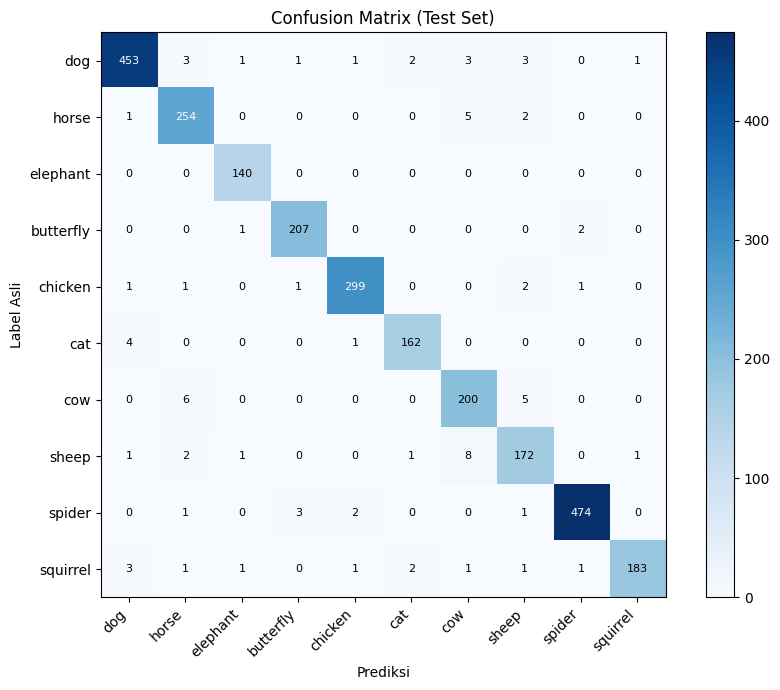

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

# Kumpulkan label asli & prediksi dalam SATU lintasan agar urutan konsisten.
y_true, y_pred = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

print(classification_report(y_true, y_pred, target_names=en_class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.colorbar()
ticks = np.arange(num_classes)
plt.xticks(ticks, en_class_names, rotation=45, ha="right")
plt.yticks(ticks, en_class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.ylabel("Label Asli")
plt.xlabel("Prediksi")
plt.tight_layout()
plt.show()

## 8. Visualisasi Akurasi & Loss

Plot di bawah memperlihatkan perkembangan akurasi dan loss (train vs validation) sepanjang
pelatihan. Garis putus-putus menandai transisi dari Tahap 1 (*feature extraction*) ke
Tahap 2 (*fine-tuning*).

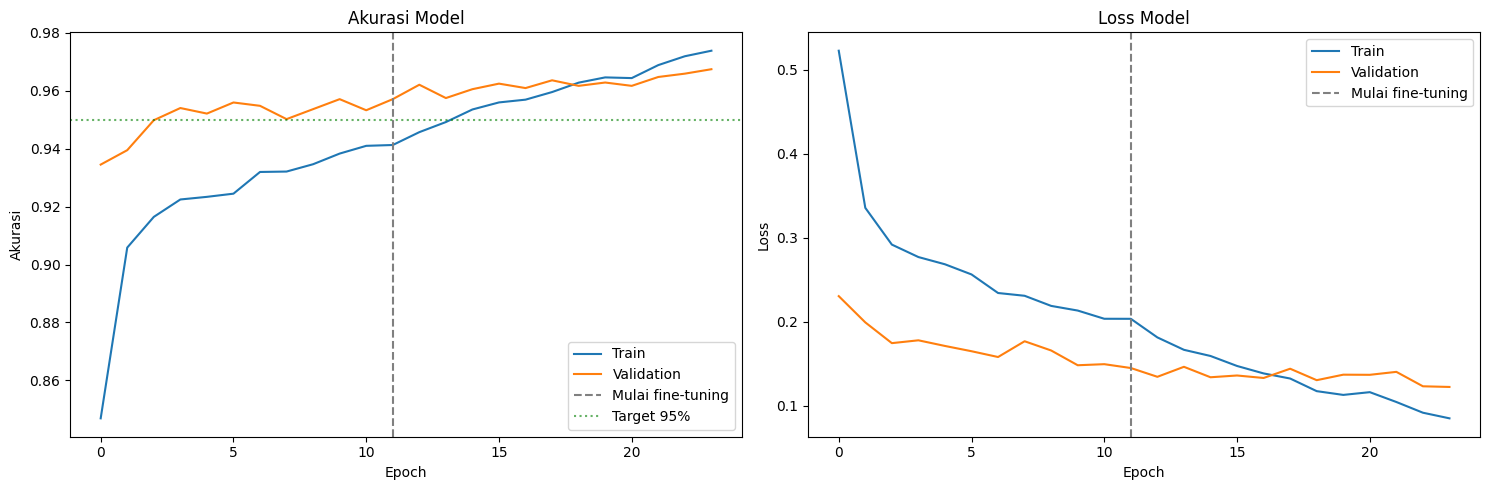

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history["accuracy"], label="Train")
ax1.plot(history["val_accuracy"], label="Validation")
ax1.axvline(phase1_epochs - 1, color="gray", ls="--", label="Mulai fine-tuning")
ax1.axhline(0.95, color="green", ls=":", alpha=0.6, label="Target 95%")
ax1.set_title("Akurasi Model"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Akurasi"); ax1.legend()

ax2.plot(history["loss"], label="Train")
ax2.plot(history["val_loss"], label="Validation")
ax2.axvline(phase1_epochs - 1, color="gray", ls="--", label="Mulai fine-tuning")
ax2.set_title("Loss Model"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend()

plt.tight_layout()
plt.show()

## 9. Ekspor — SavedModel

Pada Keras 3 (default Colab), `model.save()` menulis format `.keras`. Untuk menghasilkan
**direktori SavedModel** (`saved_model.pb` + `variables/`) digunakan `model.export()`.

⚠️ **Penting:** lapisan augmentasi (`RandomRotation` / `RandomZoom`) memakai op
`ImageProjectiveTransformV3` yang **tidak didukung TF-Lite**, sehingga konversi `.tflite`
akan gagal bila lapisan ini ikut diekspor. Karena augmentasi hanya diperlukan saat *training*
(bukan saat deployment), kita ekspor **model inferensi tanpa lapisan augmentasi** —
bobot hasil pelatihan tetap dipakai, tanpa perlu melatih ulang.

In [53]:
SAVED_MODEL_DIR = "saved_model"

# Buang lapisan augmentasi (indeks 0); lapisan lain memakai bobot hasil pelatihan.
inference_model = tf.keras.Sequential(
    [tf.keras.Input(shape=IMG_SIZE + (3,))] + model.layers[1:],
    name="animals10_inference",
)
inference_model.export(SAVED_MODEL_DIR)
print("Lapisan model inferensi :", [l.name for l in inference_model.layers])
print("Isi SavedModel          :", os.listdir(SAVED_MODEL_DIR))

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_521')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140234682901392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682899856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682900816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682902928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682905616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682904080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682902160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682905232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140234682902736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140235515759504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14023468290254

## 10. Ekspor — TF-Lite

Konversi dilakukan dari direktori SavedModel (jalur paling andal di Keras 3). Kita juga
menulis `label.txt` sesuai urutan indeks kelas model.

In [54]:
os.makedirs("tflite", exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # kuantisasi bobot -> berkas lebih kecil
tflite_model = converter.convert()

with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

# label.txt: satu nama kelas (Inggris) per baris, sesuai urutan indeks 0..9.
with open("tflite/label.txt", "w") as f:
    f.write("\n".join(en_class_names))

print("Ukuran model.tflite : %.2f MB" % (os.path.getsize("tflite/model.tflite") / 1e6))
print("label.txt           :", en_class_names)

Ukuran model.tflite : 5.78 MB
label.txt           : ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


## 11. Inferensi (Bukti Menggunakan Model TF-Lite)

Sebagai bukti inferensi (salah satu saran penilaian), kita memuat **model TF-Lite** dan
memprediksi beberapa gambar dari **test set**. Karena lapisan *rescaling* berada di dalam
model, masukan TF-Lite adalah piksel mentah rentang `[0, 255]`.

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


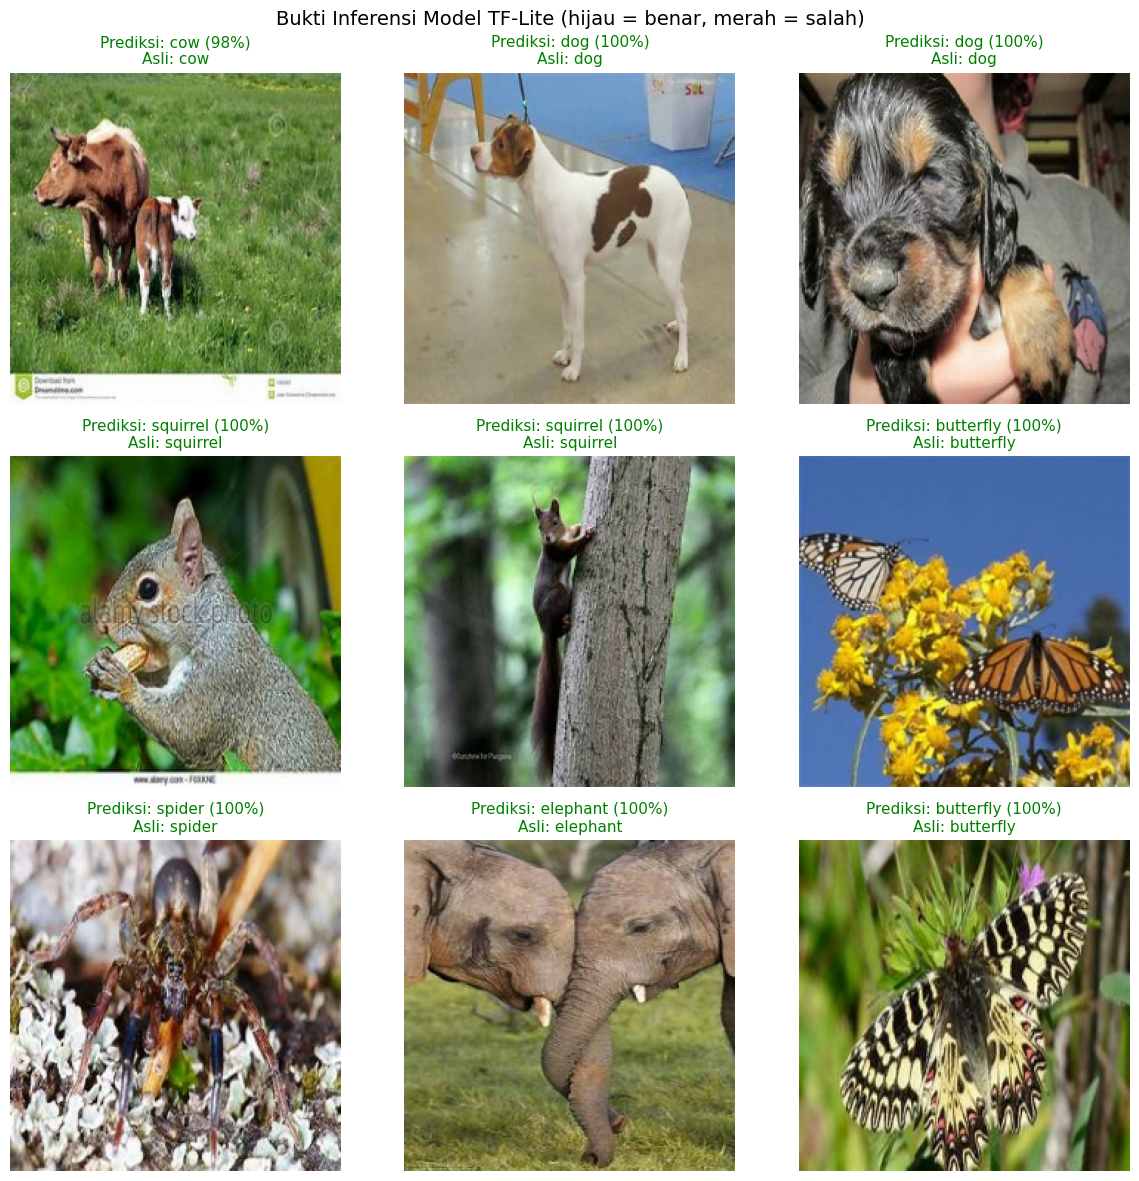

In [55]:
interpreter = tf.lite.Interpreter(model_path="tflite/model.tflite")
interpreter.allocate_tensors()
in_idx = interpreter.get_input_details()[0]["index"]
out_idx = interpreter.get_output_details()[0]["index"]


def tflite_predict(image):
    """Prediksi satu gambar (H,W,3) float32 -> (indeks_kelas, confidence)."""
    x = np.expand_dims(image.astype(np.float32), axis=0)
    interpreter.set_tensor(in_idx, x)
    interpreter.invoke()
    probs = interpreter.get_tensor(out_idx)[0]
    return int(np.argmax(probs)), float(np.max(probs))


# Ambil satu batch dari test set lalu tampilkan 9 prediksi.
images, labels = next(iter(test_ds))
plt.figure(figsize=(12, 12))
for i in range(9):
    pred_idx, conf = tflite_predict(images[i].numpy())
    true_idx = int(labels[i].numpy())
    correct = pred_idx == true_idx
    ax = plt.subplot(3, 3, i + 1)
    ax.imshow(images[i].numpy().astype("uint8"))
    ax.set_title(
        f"Prediksi: {en_class_names[pred_idx]} ({conf:.0%})\nAsli: {en_class_names[true_idx]}",
        color="green" if correct else "red", fontsize=11)
    ax.axis("off")
plt.suptitle("Bukti Inferensi Model TF-Lite (hijau = benar, merah = salah)", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Ekspor — TensorFlow.js

`tensorflowjs_converter` berjalan sebagai **subprocess** yang membaca direktori `saved_model/`
di disk, jadi tidak terpengaruh versi TF di kernel. Kita instal `tensorflowjs` **lengkap**
(beserta seluruh dependensinya — termasuk `tensorflow_decision_forests` & `tf-keras`) dan
menjalankannya **paling akhir** agar perubahan versi paket tidak mengganggu sel-sel sebelumnya.

> Catatan: instalasi penuh mungkin menampilkan peringatan "incompatible" dan sempat mengubah
> versi TF/numpy di kernel — ini **aman** karena seluruh langkah TF lain sudah selesai dan
> artefak (`saved_model/`, `tflite/`) sudah tersimpan di disk.

In [56]:
# Instal tensorflowjs LENGKAP (jangan pakai --no-deps) agar semua dependensi converter tersedia.
!pip install -q tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 810.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
bigquery-magics 0.14.0 requires packaging>=24.2.0, bu

In [57]:
# Konversi SavedModel -> TensorFlow.js graph model.
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    --signature_name=serving_default \
    --saved_model_tags=serve \
    saved_model tfjs_model

print("Isi tfjs_model:", os.listdir("tfjs_model"))

2026-05-24 15:57:58.217388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779638278.603790   43755 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779638278.725859   43755 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779638279.470938   43755 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779638279.470990   43755 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779638279.471000   43755 computation_placer.cc:177] computation placer alr

## 13. requirements.txt

Hasilkan daftar dependensi dari lingkungan eksekusi. (Sebagai alternatif yang lebih ringkas,
dapat digunakan `pipreqs` yang hanya mencantumkan paket yang benar-benar di-*import*.)

In [58]:
!pip freeze > requirements.txt
print("requirements.txt dibuat. Cuplikan paket inti:")
!grep -Ei "^(tensorflow|tensorflowjs|keras|numpy|matplotlib|pillow|scikit-learn|kaggle)" requirements.txt

requirements.txt dibuat. Cuplikan paket inti:
kaggle==2.1.2
kagglehub==1.0.0
kagglesdk==0.1.23
keras==3.13.2
keras-hub==0.26.0
keras-nlp==0.26.0
matplotlib==3.10.0
matplotlib-inline==0.2.1
matplotlib-venn==1.1.2
numpy==2.0.2
pillow==11.3.0
scikit-learn==1.6.1
tensorflow==2.19.0
tensorflow-datasets==4.9.9
tensorflow-hub==0.16.1
tensorflow-metadata==1.17.3
tensorflow-probability==0.25.0
tensorflow-text==2.20.1
tensorflow_decision_forests==1.12.0
tensorflowjs==4.22.0


## Ringkasan

- Model `Sequential` (MobileNetV2 + `Conv2D`/`MaxPooling2D` + kepala `Dense`) dilatih dua tahap.
- Akurasi training & test ditampilkan pada sel Evaluasi (target ≥ 95%).
- Plot akurasi & loss, *confusion matrix*, dan **bukti inferensi TF-Lite** tersedia di atas.
- Model diekspor ke **SavedModel** (`saved_model/`), **TF-Lite** (`tflite/`), dan
  **TensorFlow.js** (`tfjs_model/`).

**Langkah berikutnya (lihat README / INSTRUCTIONS):** unduh `notebook.ipynb` (sudah berisi
output) **dan** `notebook.py` dari Colab, lalu susun semuanya ke dalam folder `submission/`
dan kompres menjadi `.zip` sebelum dikirim ke Dicoding.